# NPL 예측 ML 모델링 v2 — 이전 분기 NPL 추가

v1과 달라진 점:
- 피처에 NPL_lag1(이전 분기 NPL비율) 추가
- 거시지표(현재값 + lag1 + diff1) + 이전 NPL
- Train: 2011Q4~2022Q4 / Test: 2023Q1~2025Q3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model  import LinearRegression, Ridge, Lasso
from sklearn.ensemble      import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import mean_squared_error, mean_absolute_error, r2_score
from xgboost               import XGBRegressor
from lightgbm              import LGBMRegressor

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# -------------------------------------------------------
# 1. 데이터 로드 및 피처 엔지니어링
# -------------------------------------------------------
df = pd.read_csv('../data/processed/dataset.csv')

# 거시경제 지표 컬럼
macro_cols = ['base_rate', 'deposit_rate', 'loan_rate',
              'unemployment_rate', 'household_loan_balance']

# (1) 거시지표 Lag1 피처
for col in macro_cols:
    df[col + '_lag1']  = df[col].shift(1)

# (2) 거시지표 Diff1 피처 (전 분기 대비 변화량)
for col in macro_cols:
    df[col + '_diff1'] = df[col].diff(1)

# (3) [NEW] 이전 분기 NPL 피처 — 자기회귀 효과 포착
df['NPL_lag1'] = df['NPL비율'].shift(1)

# (4) 예측 타겟: 현재 분기 피처 -> 다음 분기 NPL
df['target_npl'] = df['NPL비율'].shift(-1)

# NaN 행 제거 (첫 행: lag 없음, 마지막 행: target 없음)
df_model = df.dropna().reset_index(drop=True)

print('모델링 데이터 크기:', df_model.shape)
print('기간:', df_model['quarter'].iloc[0], '~', df_model['quarter'].iloc[-1])

모델링 데이터 크기: (55, 22)
기간: 2012Q1 ~ 2025Q3


In [3]:
# -------------------------------------------------------
# 2. Train / Test 분할
# -------------------------------------------------------
macro_features = (
    macro_cols
    + [c + '_lag1'  for c in macro_cols]
    + [c + '_diff1' for c in macro_cols]
)
feature_cols = macro_features + ['NPL_lag1']   # v2: NPL lag 추가

train_mask = df_model['quarter'] <= '2022Q4'
test_mask  = df_model['quarter'] >= '2023Q1'

X_train = df_model.loc[train_mask, feature_cols]
y_train = df_model.loc[train_mask, 'target_npl']
X_test  = df_model.loc[test_mask,  feature_cols]
y_test  = df_model.loc[test_mask,  'target_npl']
test_quarters = df_model.loc[test_mask, 'quarter'].tolist()

print(f'Train: {len(X_train)}개 ({df_model.loc[train_mask, "quarter"].iloc[0]} ~ {df_model.loc[train_mask, "quarter"].iloc[-1]})')
print(f'Test : {len(X_test)}개  ({test_quarters[0]} ~ {test_quarters[-1]})')
print(f'피처 수: {len(feature_cols)}개  (거시지표 {len(macro_features)}개 + NPL_lag1 1개)')

Train: 44개 (2012Q1 ~ 2022Q4)
Test : 11개  (2023Q1 ~ 2025Q3)
피처 수: 16개  (거시지표 15개 + NPL_lag1 1개)


In [4]:
# -------------------------------------------------------
# 3. 스케일링 및 모델 정의 (기본 파라미터)
# -------------------------------------------------------
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    'Linear Regression': (LinearRegression(),                            True),
    'Ridge':             (Ridge(alpha=1.0),                              True),
    'Lasso':             (Lasso(alpha=0.001),                            True),
    'Random Forest':     (RandomForestRegressor(
                              n_estimators=200, max_depth=4,
                              random_state=42),                          False),
    'XGBoost':           (XGBRegressor(
                              n_estimators=200, max_depth=3,
                              learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42, verbosity=0),             False),
    'LightGBM':          (LGBMRegressor(
                              n_estimators=200, max_depth=3,
                              learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42, verbose=-1),              False),
}

print('모델 정의 완료')

모델 정의 완료


In [5]:
# -------------------------------------------------------
# 4. 모델 학습 및 평가
# -------------------------------------------------------
results     = []
predictions = {}

for name, (model, use_scale) in models.items():
    Xtr = X_train_scaled if use_scale else X_train.values
    Xte = X_test_scaled  if use_scale else X_test.values

    model.fit(Xtr, y_train)

    y_pred_train = model.predict(Xtr)
    y_pred_test  = model.predict(Xte)
    predictions[name] = y_pred_test

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    mae_test   = mean_absolute_error(y_test,  y_pred_test)
    r2_test    = r2_score(y_test, y_pred_test)
    mape_test  = np.mean(np.abs((y_test.values - y_pred_test) / y_test.values)) * 100

    results.append({
        '모델':         name,
        'RMSE(Train)': round(rmse_train, 4),
        'RMSE(Test)':  round(rmse_test,  4),
        'MAE(Test)':   round(mae_test,   4),
        'R2(Test)':    round(r2_test,    4),
        'MAPE(Test)':  round(mape_test,  2),
    })

result_df = pd.DataFrame(results).sort_values('RMSE(Test)')
print('=== v2 모델 성능 비교 (NPL_lag1 포함) ===')
print(result_df.to_string(index=False))

=== v2 모델 성능 비교 (NPL_lag1 포함) ===
               모델  RMSE(Train)  RMSE(Test)  MAE(Test)  R2(Test)  MAPE(Test)
    Random Forest       0.0535      0.0839     0.0759   -1.1258       14.15
          XGBoost       0.0040      0.1162     0.1054   -3.0780       19.52
         LightGBM       0.1745      0.1963     0.1865  -10.6477       37.61
            Ridge       0.0917      0.5437     0.5353  -88.3450      103.04
            Lasso       0.0881      0.7894     0.7813 -187.3058      150.78
Linear Regression       0.0875      0.8788     0.8700 -232.3646      168.07


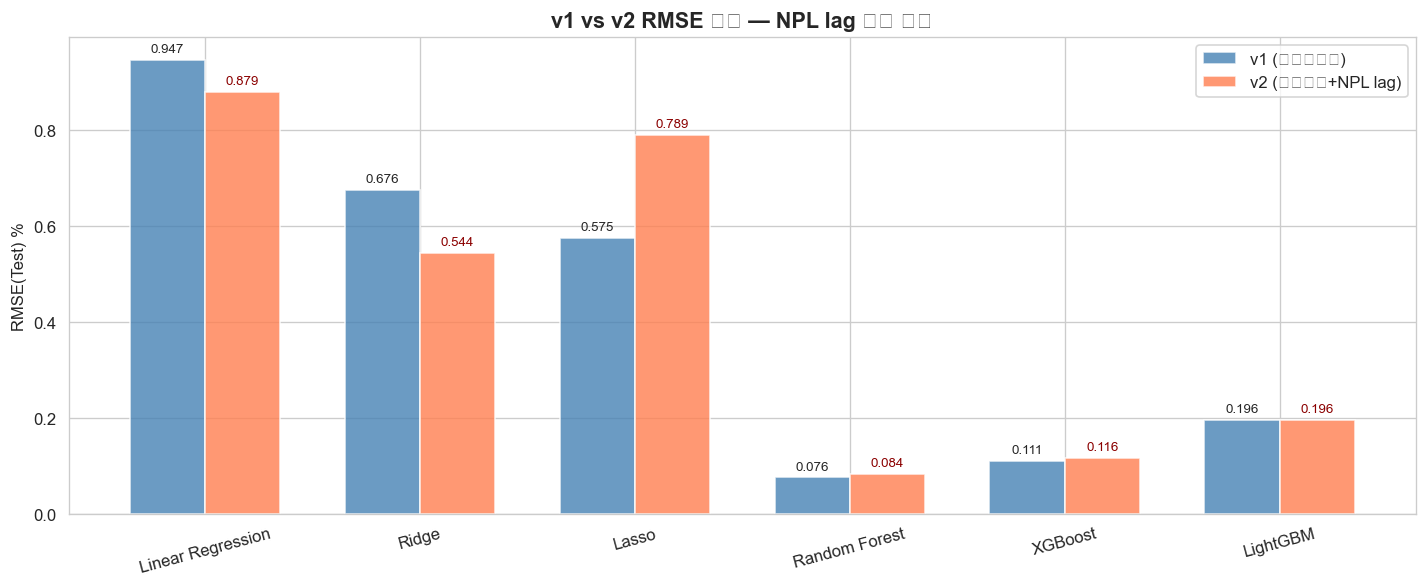

In [6]:
# -------------------------------------------------------
# 5. v1 vs v2 성능 비교 시각화
# -------------------------------------------------------
# v1 결과 (하드코딩 — 이전 노트북 결과값)
v1_rmse = {
    'Linear Regression': 0.9466,
    'Ridge':             0.6758,
    'Lasso':             0.5752,
    'Random Forest':     0.0761,
    'XGBoost':           0.1106,
    'LightGBM':          0.1959,
}
v2_rmse = dict(zip(result_df['모델'], result_df['RMSE(Test)']))

model_names = list(v1_rmse.keys())
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [v1_rmse[m] for m in model_names],
               width, label='v1 (거시지표만)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [v2_rmse[m] for m in model_names],
               width, label='v2 (거시지표+NPL lag)', color='coral', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='darkred')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel('RMSE(Test) %')
ax.set_title('v1 vs v2 RMSE 비교 — NPL lag 추가 효과', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_v1_vs_v2.png', bbox_inches='tight')
plt.show()

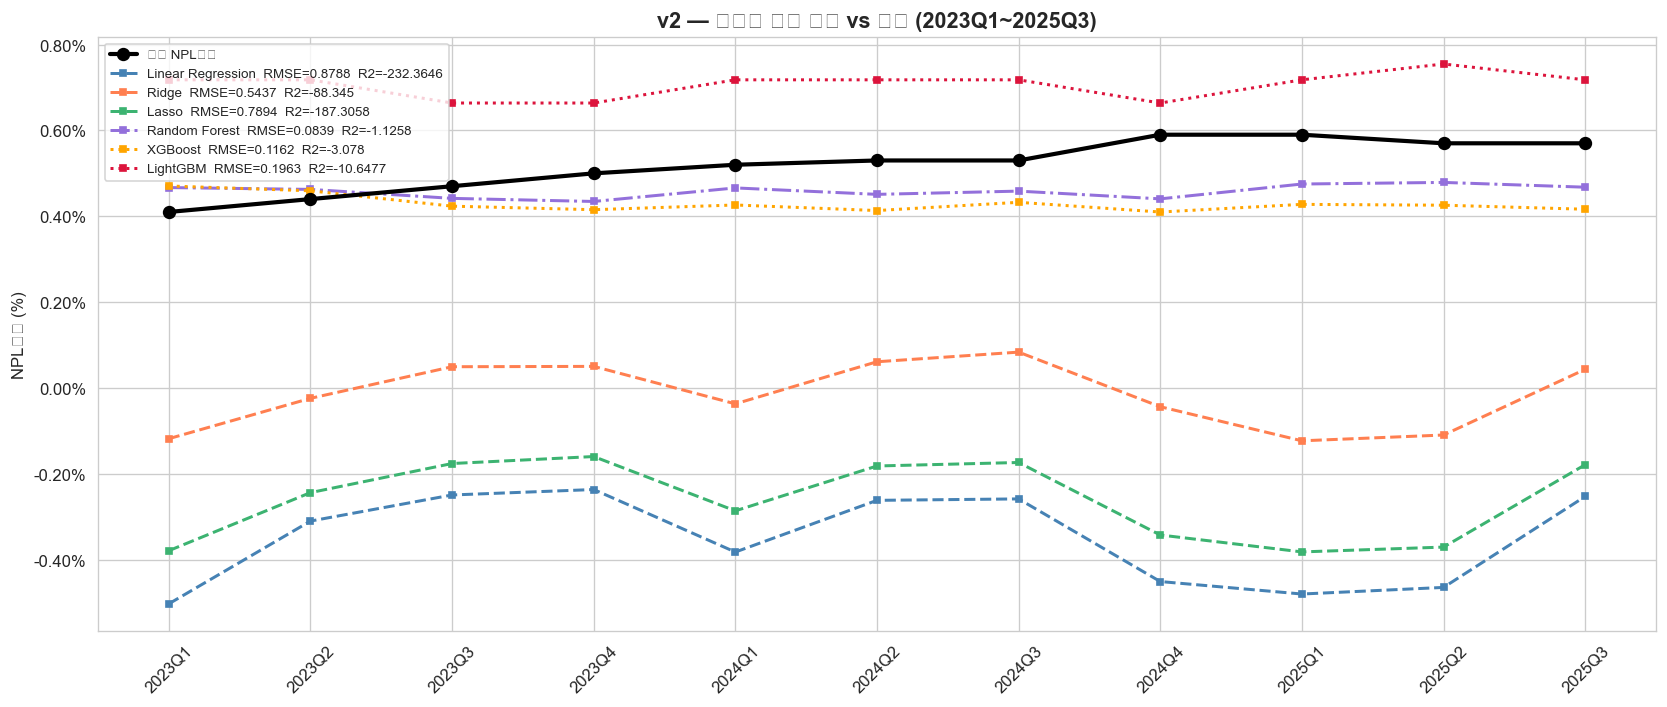

In [7]:
# -------------------------------------------------------
# 6. 예측 vs 실제 시계열
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

x_range = range(len(test_quarters))
ax.plot(x_range, y_test.values, 'ko-', linewidth=2.5,
        markersize=7, label='실제 NPL비율', zorder=5)

colors     = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'orange', 'crimson']
linestyles = ['--', '--', '--', '-.', ':', ':']

for (name, preds), color, ls in zip(predictions.items(), colors, linestyles):
    rmse = result_df.loc[result_df['모델'] == name, 'RMSE(Test)'].values[0]
    r2   = result_df.loc[result_df['모델'] == name, 'R2(Test)'].values[0]
    ax.plot(x_range, preds, color=color, linestyle=ls, linewidth=1.8,
            marker='s', markersize=4,
            label=f'{name}  RMSE={rmse}  R2={r2}')

ax.set_xticks(x_range)
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('NPL비율 (%)')
ax.set_title('v2 — 테스트 기간 예측 vs 실제 (2023Q1~2025Q3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.savefig('../data/processed/fig_v2_prediction.png', bbox_inches='tight')
plt.show()

최고 성능 모델: Random Forest
  RMSE : 0.0839%
  MAE  : 0.0759%
  R2   : -1.1258
  MAPE : 14.15%


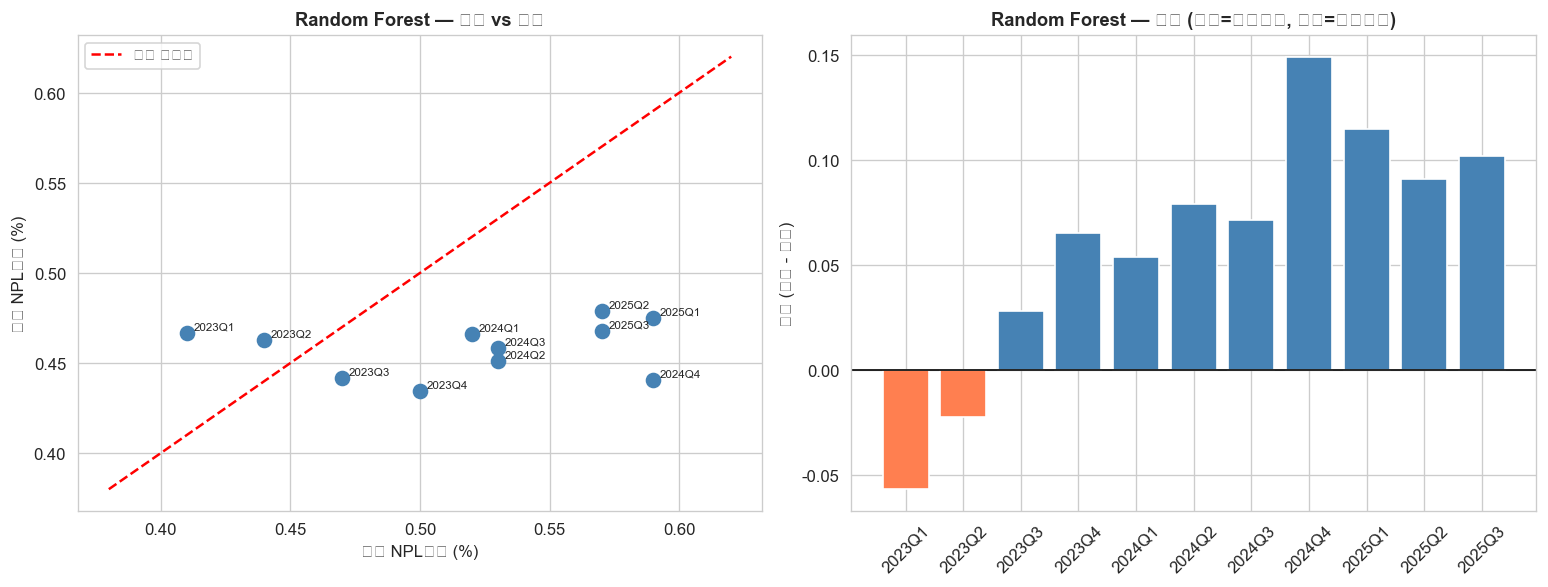

In [8]:
# -------------------------------------------------------
# 7. 최고 성능 모델 심층 분석
# -------------------------------------------------------
best_name  = result_df.iloc[0]['모델']
best_preds = predictions[best_name]
residuals  = y_test.values - best_preds

print(f'최고 성능 모델: {best_name}')
print(f'  RMSE : {result_df.iloc[0]["RMSE(Test)"]:.4f}%')
print(f'  MAE  : {result_df.iloc[0]["MAE(Test)"]:.4f}%')
print(f'  R2   : {result_df.iloc[0]["R2(Test)"]:.4f}')
print(f'  MAPE : {result_df.iloc[0]["MAPE(Test)"]:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 실제 vs 예측 산점도
ax = axes[0]
ax.scatter(y_test, best_preds, color='steelblue', s=70, zorder=3)
lim = [min(y_test.min(), best_preds.min()) - 0.03,
       max(y_test.max(), best_preds.max()) + 0.03]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='완벽 예측선')
for actual, pred, q in zip(y_test, best_preds, test_quarters):
    ax.annotate(q, (actual, pred), textcoords='offset points',
                xytext=(4, 2), fontsize=7)
ax.set_xlabel('실제 NPL비율 (%)')
ax.set_ylabel('예측 NPL비율 (%)')
ax.set_title(f'{best_name} — 실제 vs 예측', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# 잔차
ax = axes[1]
colors_bar = ['coral' if r < 0 else 'steelblue' for r in residuals]
ax.bar(range(len(test_quarters)), residuals, color=colors_bar, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(test_quarters)))
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('잔차 (실제 - 예측)')
ax.set_title(f'{best_name} — 잔차 (파랑=과소예측, 빨강=과대예측)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fig_v2_best_model.png', bbox_inches='tight')
plt.show()

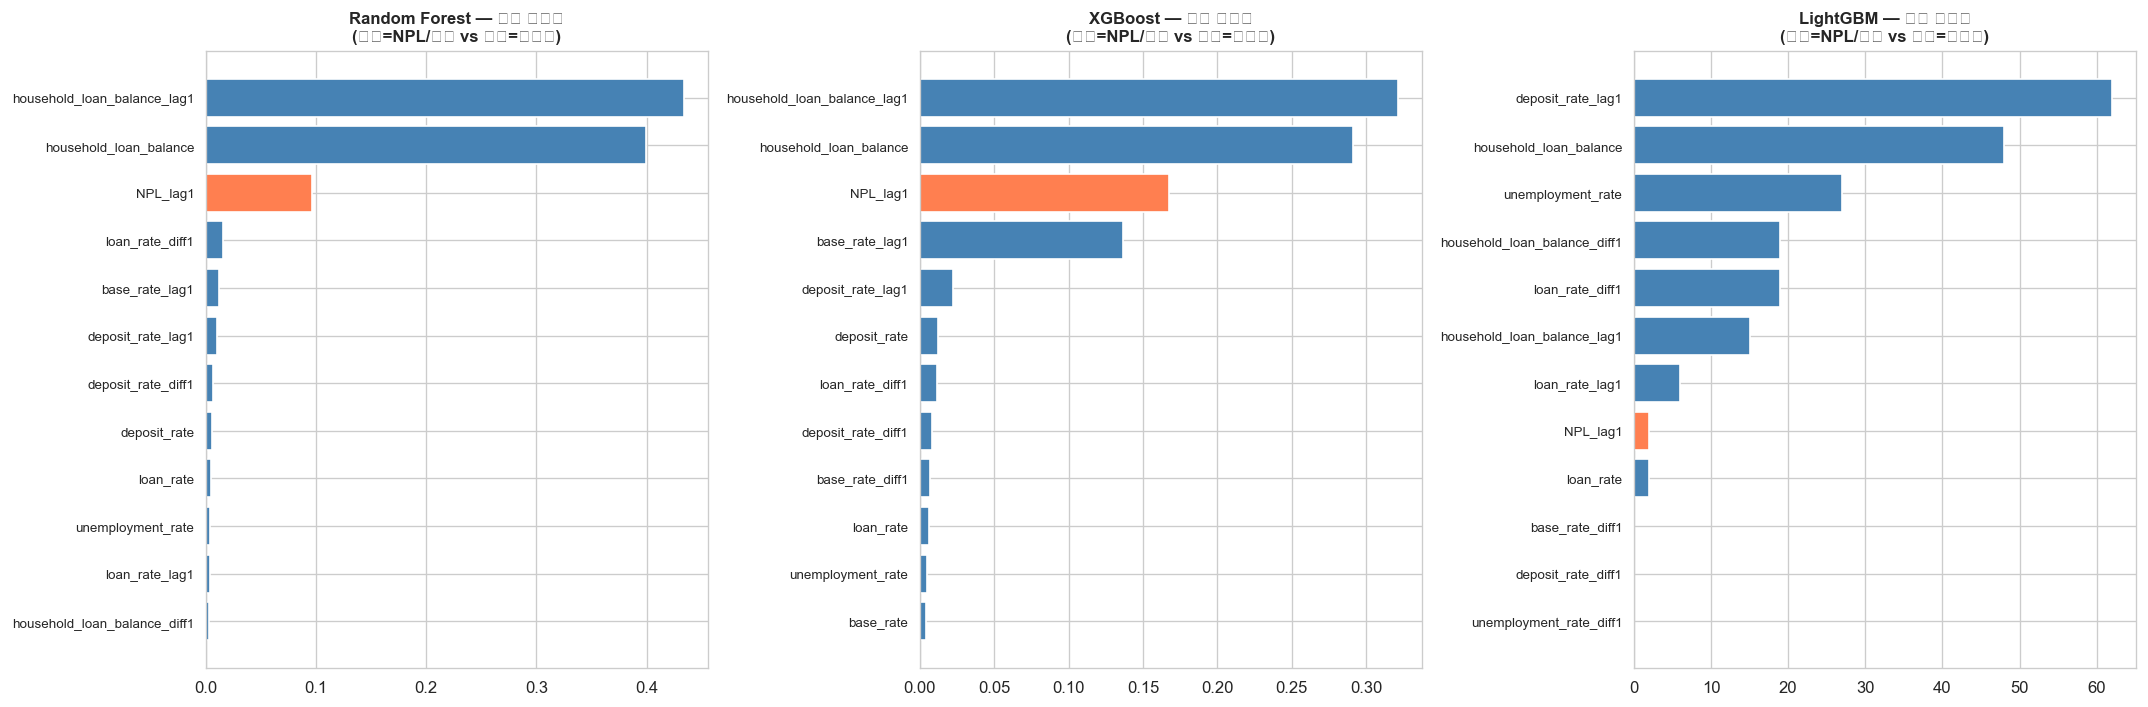

In [9]:
# -------------------------------------------------------
# 8. 피처 중요도 (트리 기반 모델)
# -------------------------------------------------------
tree_models = {
    'Random Forest': models['Random Forest'][0],
    'XGBoost':       models['XGBoost'][0],
    'LightGBM':      models['LightGBM'][0],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, model) in zip(axes, tree_models.items()):
    imp_df = pd.DataFrame({'피처': feature_cols,
                           '중요도': model.feature_importances_})
    imp_df = imp_df.sort_values('중요도', ascending=True).tail(12)
    colors_imp = ['coral' if '비율' in f or 'NPL' in f else 'steelblue'
                  for f in imp_df['피처']]
    ax.barh(imp_df['피처'], imp_df['중요도'],
            color=colors_imp, edgecolor='white')
    ax.set_title(f'{name} — 피처 중요도\n(빨강=NPL/거시 vs 파랑=나머지)',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_v2_importance.png', bbox_inches='tight')
plt.show()

In [10]:
# -------------------------------------------------------
# 9. 분기별 상세 예측 결과
# -------------------------------------------------------
def next_quarter_label(q):
    """'2023Q1' -> '2023Q2', '2023Q4' -> '2024Q1'"""
    year, qnum = int(q[:4]), int(q[-1])
    if qnum < 4:
        return f'{year}Q{qnum+1}'
    return f'{year+1}Q1'

detail_df = pd.DataFrame({
    '입력분기':     test_quarters,
    '예측대상분기': [next_quarter_label(q) for q in test_quarters],
    '실제NPL(%)':  y_test.values.round(3),
    f'예측({best_name})(%)': best_preds.round(3),
    '오차(%)':     residuals.round(3),
})
print(f'=== {best_name} 분기별 예측 결과 ===')
print(detail_df.to_string(index=False))
print(f'\n평균 절대 오차 : {np.abs(residuals).mean():.4f}%')
print(f'MAPE           : {np.mean(np.abs(residuals/y_test.values))*100:.2f}%')

=== Random Forest 분기별 예측 결과 ===
  입력분기 예측대상분기  실제NPL(%)  예측(Random Forest)(%)  오차(%)
2023Q1 2023Q2      0.41                 0.467 -0.057
2023Q2 2023Q3      0.44                 0.463 -0.023
2023Q3 2023Q4      0.47                 0.442  0.028
2023Q4 2024Q1      0.50                 0.434  0.066
2024Q1 2024Q2      0.52                 0.466  0.054
2024Q2 2024Q3      0.53                 0.451  0.079
2024Q3 2024Q4      0.53                 0.459  0.071
2024Q4 2025Q1      0.59                 0.441  0.149
2025Q1 2025Q2      0.59                 0.475  0.115
2025Q2 2025Q3      0.57                 0.479  0.091
2025Q3 2025Q4      0.57                 0.468  0.102

평균 절대 오차 : 0.0759%
MAPE           : 14.15%
